In [281]:
# Import Libraries and Configure Matplotlib
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import re
import collections
from matplotlib import cm
from matplotlib import colors
from pycirclize import Circos
from tqdm import tqdm
import glob
import pandas as pd
import sys
import importlib
sys.path.append('../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.circ as circ
# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(circ)

<module 'utilities.circ' from '/Users/xuechenkan/potts_model_test/ms0.5/../utilities/circ.py'>

In [282]:
INSTI_list = [
    "M50I", "H51Y", "T66A/I/K", "L74M/I/F", "E92Q/G/V", "Q95K", "T97A", "G118R", "F121Y",
    "E138K/A/T", "G140S/A/C/R", "Y143C/R/H/K/S/G/A", "P145S", "Q146P", "S147G", "Q148H/K/R/N",
    "G149A", "V151I/L/A", "S153Y/F/A", "N155H/S/T/D", "E157Q", "G163R/K", "S230R", "D232N", "R263K"
]
PI_list = [
    "L10F/I/V/R/Y", "V11I/L", "K20R/I/M/T/V", "L23I", "L24I/F/M", "D30N", "V32I", "L33F", "M36I",
    "K43T", "M46I/L/V", "I47V/A", "G48V/M/A/S/T/Q", "I50V/L", "F53L/Y", "I54V/A/S/T/L/M", "Q58E",
    "A71V/T/I/L", "G73S/T/C/A/D/V", "T74P/S", "L76V", "V82A/T/S/F/L/M/C", "N83D/S", "I84V/A/C",
    "I85V", "N88D/S/T/G", "L89V/T", "L90M"
]

#also: , "Beta3-Beta4 Insertions", "Beta3-Beta4 Deletions"
NRTI_list = [
"E40F", "M41L", "E44D/A", "A62V", "K65R", "D67N", "D67G/E",
"S68G/N/D", "T69S", "T69D/N/S/G", "K70R", "K70E/G/Q/T/N/S",
"L74V/I", "V75T/M/A/S", "Y115F", "V118I", "Q151M", "M184V/I",
"L210W", "T215C/D/E/F/I/S/V/Y", "K219Q/E", "K219N/R", "N348I"
]

NNRTI_list = [
    "V90I", "A98G", "L100I", "K101E/H/P/Q/R/N", "K103N/S/H/T/R/Q/E", "V106A/M/I", "V108I",
    "E138K/A/G/Q/R", "V179D/E/F/I/L/T", "Y181C/I/V", "Y188L/C/H", "G190A/S/E/Q", "H221Y",
    "P225H", "F227L/C/I/V", "M230L/I", "Y232H", "L234I", "P236L", "K238T/N", "Y318F", "N348I"
]

NRTI_NNRTI_combined_list = ["E40F", "M41L", "E44D/A", "A62V", "K65R",
 "D67N", "D67G/E", "S68G/N/D", "T69S", "T69D/N/S/G", "K70R", "K70E/G/Q/T/N/S", 
 "L74V/I", "V75T/M/A/S", "V90I", "A98G", "L100I", "K101E/H/P/Q/R/N", 
 "K103N/S/H/T/R/Q/E", "V106A/M/I", "V108I", "Y115F", "V118I", "E138K/A/G/Q/R", 
 "V179D/E/F/I/L/T", "Y181C/I/V", "Y188L/C/H", "G190A/S/E/Q", "Q151M", "H221Y", 
 "P225H", "F227L/C/I/V", "M230L/I", "Y232H", "L234I", "P236L", "K238T/N", 
 "M184V/I", "L210W", "T215C/D/E/F/I/S/V/Y", "K219Q/E", 
"K219N/R", "Y318F", "N348I", "N348I"]






In [283]:
functions.split_pair_multiple_mt('L100I')

(100, 'L', ['I'])

In [284]:
start_aa_IN = 1  # Starting amino acid position
actual_length_IN = 263
start_aa_PR = 1  # Starting amino acid position
actual_length_PR = 99
start_aa_RT = 39  # Starting amino acid position
actual_length_RT = 188


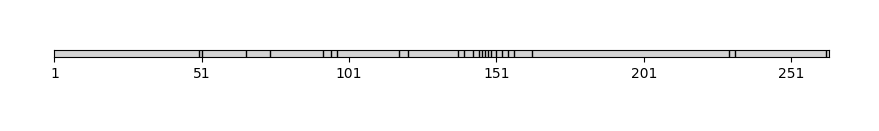

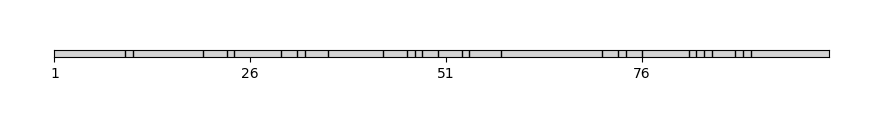

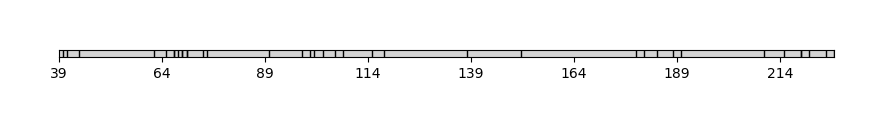

In [285]:
IN_to_annotate = []
for mutation in INSTI_list:
    position, wt, mt = functions.split_pair_multiple_mt(mutation)
    IN_to_annotate.append((position, wt, mt))

PR_to_annotate = []
for mutation in PI_list:
    position, wt, mt = functions.split_pair_multiple_mt(mutation)
    PR_to_annotate.append((position, wt, mt))

RT_to_annotate = []
for mutation in NRTI_NNRTI_combined_list:
    position, wt, mt = functions.split_pair_multiple_mt(mutation)
    RT_to_annotate.append((position, wt, mt))

plt.figure(figsize=(10, 0.1))
plt.gca().set_facecolor('blue')  # Set the background color of the plot area to blue
plt.barh(y=1, width=actual_length_IN, left=start_aa_IN, color='lightgrey', height=10, align='edge')
plt.xlim(start_aa_IN, actual_length_IN + start_aa_IN)  # Set x-axis limits to avoid extra blue bars
plt.title("")
plt.xlabel("")
plt.yticks([])  # Remove y-axis ticks for clarity
plt.xticks(range(start_aa_IN, actual_length_IN + start_aa_IN, 50))  # Set x-axis ticks at intervals of 25
for position, wt, mt in IN_to_annotate:
    plt.axvline(x=position, color='black', linestyle='-', linewidth=1)  # Add a solid vertical line for each position
plt.savefig('Images/IN_bar.png', dpi=750, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 0.1))
plt.gca().set_facecolor('blue')  # Set the background color of the plot area to blue
plt.barh(y=1, width=actual_length_PR, left=start_aa_PR, color='lightgrey', height=0.5)
plt.xlim(start_aa_PR, actual_length_PR + start_aa_PR)  # Set x-axis limits to avoid extra blue bars
plt.title("")
plt.xlabel("")
plt.yticks([])  # Remove y-axis ticks for clarity
plt.xticks(range(start_aa_PR, actual_length_PR + start_aa_PR, 25))  # Set x-axis ticks at intervals of 25
for position, wt, mt in PR_to_annotate:
    plt.axvline(x=position, color='black', linestyle='-', linewidth=1)  # Add a solid vertical line for each position
plt.savefig('Images/PR_bar.png', dpi=750, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 0.1))
plt.gca().set_facecolor('blue')  # Set the background color of the plot area to blue
plt.barh(y=1, width=actual_length_RT, left=start_aa_RT, color='lightgrey', height=0.5)
plt.xlim(start_aa_RT, actual_length_RT + start_aa_RT)  # Set x-axis limits to avoid extra blue bars
plt.title("")
plt.xlabel("")
plt.yticks([])  # Remove y-axis ticks for clarity
plt.xticks(range(start_aa_RT, actual_length_RT + start_aa_RT, 25))  # Set x-axis ticks at intervals of 25
for position, wt, mt in RT_to_annotate:
    if int(position) <= start_aa_RT+actual_length_RT:
        # print(position, wt, mt)
        plt.axvline(x=position, color='black', linestyle='-', linewidth=1)  # Add a solid vertical line for each position
plt.savefig('Images/RT_bar.png', dpi=750, bbox_inches='tight')
plt.show()